# Necessary Imports for the Notebook

The examples in this notebook require the following imports.
Make sure to run this cell before any other cell.




In [1]:
pip install skfeature-chappers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 4.8 MB/s eta 0:00:00


In [2]:
pip install nanopq

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nanopq import PQ  # Make sure you have nanopq installed: pip install nanopq
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from skfeature.function.information_theoretical_based import CMIM, JMI
import gc
import time
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score

In [4]:
import scipy.spatial as ss
from scipy.special import digamma
from math import log
import numpy.random as nr
import numpy as np
import random
def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

In [5]:
import numpy as np
from math import log

def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

def fast_cmim(X, y, **kwargs):
    """
    This function implements the CMIM feature selection.
    Input
    -----
    X: {numpy array}, shape (n_samples, n_features)
        Input data, guaranteed to be a discrete numpy array
    y: {numpy array}, shape (n_samples,)
        guaranteed to be a numpy array
    kwargs: {dictionary}
        n_selected_features: {int}
            number of features to select
    Output
    ------
    F: {numpy array}, shape (n_features,)
        index of selected features, F[0] is the most important feature
    t1: {numpy array}, shape: (n_features,)
        minimal corresponding mutual information between selected features and response when
        conditionned on a previously selected feature
    Reference
    ---------
    Fleuret 2004 - Fast Binary Feature Selection with Conditional Mutual Information
    http://www.idiap.ch/~fleuret/papers/fleuret-jmlr2004.pdf
    """

    n_samples, n_features = X.shape
    is_n_selected_features_specified = False

    if 'n_selected_features' in kwargs.keys():
        n_selected_features = kwargs['n_selected_features']
        is_n_selected_features_specified = True
        F = np.nan * np.zeros(n_selected_features)
    else:
        F = np.nan * np.zeros(n_features)

    # t1
    t1 = np.zeros(n_features)

    # m is a counting indicator
    m = np.zeros(n_features) - 1

    for i in range(n_features):
        f = X[:, i]
        t1[i] = midd(f, y)


    for k in range(n_features):
        ### uncomment to keep track
        # counter = int(np.sum(~np.isnan(F)))
        # if counter%5 == 0 or counter <= 1:
        #     print("F contains %s features"%(counter))
        if k == 0:
            # select the feature whose mutual information is the largest
            idx = np.argmax(t1)
            F[0] = idx
            f_select = X[:, idx]

        if is_n_selected_features_specified:
            if np.sum(~np.isnan(F)) == n_selected_features:
                break

        sstar = -1000000 # start with really low value for best partial score sstar
        for i in range(n_features):

            if i not in F:

                while (t1[i] > sstar) and (m[i]<k-1) :
                    m[i] = m[i] + 1
                    t1[i] = min(t1[i], cmidd(X[:,i], # feature i
                                             y,  # target
                                             X[:, int(F[int(m[i])])] # conditionned on selected features
                                            )
                               )
                if t1[i] > sstar:
                    sstar = t1[i]
                    F[k+1] = i

    F = np.array(F[F>-100])
    F = F.astype(int)
    t1 = t1[F]
    return (F, t1)

# **Reading CSV file**

In [8]:
# Load data
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Malgenome.csv")
#data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-CIC-2020.csv")
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)

In [ ]:
data

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED,Class
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1
4,1,1,1,1,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1
5074,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,1,0,0,0,0,1
5075,0,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,1
5076,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

In [ ]:
# record start time
start = time.time()
f, t = fast_cmim(X_train,y_train, n_selected_features = 100)
end = time.time()

# print the difference between start
# and end time in milli. secs
print("The time of execution of above program is :",
      (end-start), "sec")

The time of execution of above program is : 43.678600788116455 sec


In [ ]:
f

array([  0,   2,  13,   8,   5,  11,  20,  15,  35,   9,  10,  21,  16,
        12,  36,  18,  24,  42,  28,  39,  14,  44,  31,  23,  19,  51,
        32,   4,  33,  22,  30,  34,  27,  62,  45,  29,  59,  68,  66,
        50,  26,  78,  47,  65,  99,  57,  60,  71, 113,  54,  49,  46,
        17,  37,  93,  76,  77,  84, 125,   7,  75,  89,  72,  25,  86,
        55, 114, 119, 108,  87,  38, 135, 129,  91,  95,  63,  80,  53,
       100,  64,  94,   1, 110,  79,  88, 111,  40,  43, 124,  48,  90,
       126, 142, 120, 147, 106,  67,  85, 148, 134])

In [9]:
f = [0,   2,  13,   8,   5,  11,  20,  15,  35,   9,  10,  21,  16,
        12,  36,  18,  24,  42,  28,  39,  14,  44,  31,  23,  19,  51,
        32,   4,  33,  22,  30,  34,  27,  62,  45,  29,  59,  68,  66,
        50,  26,  78,  47,  65,  99,  57,  60,  71, 113,  54,  49,  46,
        17,  37,  93,  76,  77,  84, 125,   7,  75,  89,  72,  25,  86,
        55, 114, 119, 108,  87,  38, 135, 129,  91,  95,  63,  80,  53,
       100,  64,  94,   1, 110,  79,  88, 111,  40,  43, 124,  48,  90,
       126, 142, 120, 147, 106,  67,  85, 148, 134]

In [10]:
f = np.array(f)
f

array([  0,   2,  13,   8,   5,  11,  20,  15,  35,   9,  10,  21,  16,
        12,  36,  18,  24,  42,  28,  39,  14,  44,  31,  23,  19,  51,
        32,   4,  33,  22,  30,  34,  27,  62,  45,  29,  59,  68,  66,
        50,  26,  78,  47,  65,  99,  57,  60,  71, 113,  54,  49,  46,
        17,  37,  93,  76,  77,  84, 125,   7,  75,  89,  72,  25,  86,
        55, 114, 119, 108,  87,  38, 135, 129,  91,  95,  63,  80,  53,
       100,  64,  94,   1, 110,  79,  88, 111,  40,  43, 124,  48,  90,
       126, 142, 120, 147, 106,  67,  85, 148, 134])

In [11]:
selected_features_names=[]
for i in range(len(f)):
    selected_features_names.append(data.columns[f[i]])
selected_features_names

['transact',
 'onServiceConnected',
 'READ_PHONE_STATE',
 'TelephonyManager.getSubscriberId',
 'READ_SMS',
 'android.intent.action.BOOT_COMPLETED',
 'chmod',
 'GET_ACCOUNTS',
 'android.telephony.gsm.SmsManager',
 'Ljava.lang.Class.getCanonicalName',
 'Ljava.lang.Class.getMethods',
 'createSubprocess',
 'SEND_SMS',
 'Ljava.lang.Class.getField',
 '.system.bin',
 'getBinder',
 'TelephonyManager.getDeviceId',
 'CAMERA',
 'Ljava.lang.Class.getPackage',
 'INSTALL_PACKAGES',
 'Landroid.content.Context.unregisterReceiver',
 'android.intent.action.SEND',
 'TelephonyManager.getLine1Number',
 'WRITE_APN_SETTINGS',
 'Ljava.lang.Class.cast',
 'ACCESS_LOCATION_EXTRA_COMMANDS',
 'getCallingUid',
 'android.os.Binder',
 'USE_CREDENTIALS',
 'Ljava.net.URLDecoder',
 'ClassLoader',
 'MANAGE_ACCOUNTS',
 'HttpGet.init',
 'android.intent.action.TIME_SET',
 'onBind',
 'abortBroadcast',
 '.system.app',
 'SYSTEM_ALERT_WINDOW',
 'BLUETOOTH',
 'PackageInstaller',
 'Ljava.lang.Class.getDeclaredField',
 'READ_CALEN

In [12]:
len(selected_features_names)

100

# find the highest accuracy with respect to different number of features

In [15]:
knn={
    "acc":{"index":[],"val":[],},
    "per":{"index":[],"val":[],},
    "rec":{"index":[],"val":[],},
    "f1s":{"index":[],"val":[],},
    "auc":{"index":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Malgenome.csv")
for i in range(2,len(selected_features_names)+1,2):
    X = data[selected_features_names[:i]].values  # Features
    y = data.iloc[:, -1].values   # Binary labels (0 or 1)
    start = time.time()
    pq_pq = PQ(M=int(i/2), Ks=2)
    pq_pq.fit(X.astype(np.float32))
    codes_pq = pq_pq.encode(X.astype(np.float32))
    end = time.time()

    # print the difference between start
    # and end time in milli. secs
    print("The time of execution of above program is :",
          (end-start), "sec")
    X_train, X_test, y_train, y_test = train_test_split(codes_pq,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

    # Initialize a classifier
    knn_clf = KNeighborsClassifier(n_neighbors=5)
    start = time.time()
    knn_clf.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = knn_clf.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")
    knn["acc"]['val'].append(accuracy_score(y_test, y_pred))
    knn["acc"]['index'].append(i)
    knn["per"]['val'].append(precision_score(y_test, y_pred))
    knn["per"]['index'].append(i)
    knn["rec"]['val'].append(recall_score(y_test, y_pred))
    knn["rec"]['index'].append(i)
    knn["f1s"]['val'].append(f1_score(y_test, y_pred))
    knn["f1s"]['index'].append(i)

    y_prob = knn_clf.predict_proba(X_test)  # Get probability scores for ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    knn["auc"]['val'].append(auc(fpr, tpr))
    knn["auc"]['index'].append(i)

M: 1, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 1
Encoding the subspace: 0 / 1
The time of execution of above program is : 0.00800180435180664 sec
The time of execution of training the tabpfn is : 0.0022678375244140625 sec
The time of execution of testing sample with the tabpfn is : 0.00011280859549214521 sec
M: 2, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 2
Training the subspace: 1 / 2
Encoding the subspace: 0 / 2
Encoding the subspace: 1 / 2
The time of execution of above program is : 0.008327960968017578 sec
The time of execution of training the tabpfn is : 0.0017826557159423828 sec
The time of execution of testing sample with the tabpfn is : 5.80014206293061e-05 sec
M: 3, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 3
Training the subspace: 1 / 3
Training the subspace: 2 / 3
Encoding the subspace: 0 / 3
Encodin

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of testing sample with the tabpfn is : 7.31184726624977e-05 sec
M: 7, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 7
Training the subspace: 1 / 7
Training the subspace: 2 / 7
Training the subspace: 3 / 7
Training the subspace: 4 / 7
Training the subspace: 5 / 7
Training the subspace: 6 / 7
Encoding the subspace: 0 / 7
Encoding the subspace: 1 / 7
Encoding the subspace: 2 / 7
Encoding the subspace: 3 / 7
Encoding the subspace: 4 / 7
Encoding the subspace: 5 / 7
Encoding the subspace: 6 / 7
The time of execution of above program is : 0.030353069305419922 sec
The time of execution of training the tabpfn is : 0.003229379653930664 sec
The time of execution of testing sample with the tabpfn is : 7.665650112422433e-05 sec
M: 8, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 8
Training the subspace: 1 / 8
Training the subspace: 2 / 8
Training the subspace: 3 / 8
T

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of training the tabpfn is : 0.0068264007568359375 sec
The time of execution of testing sample with the tabpfn is : 8.047096372589352e-05 sec
M: 9, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 9
Training the subspace: 1 / 9
Training the subspace: 2 / 9
Training the subspace: 3 / 9
Training the subspace: 4 / 9
Training the subspace: 5 / 9
Training the subspace: 6 / 9
Training the subspace: 7 / 9
Training the subspace: 8 / 9
Encoding the subspace: 0 / 9
Encoding the subspace: 1 / 9
Encoding the subspace: 2 / 9
Encoding the subspace: 3 / 9
Encoding the subspace: 4 / 9
Encoding the subspace: 5 / 9
Encoding the subspace: 6 / 9
Encoding the subspace: 7 / 9
Encoding the subspace: 8 / 9
The time of execution of above program is : 0.035429954528808594 sec
The time of execution of training the tabpfn is : 0.0039713382720947266 sec


...

Training the subspace: 25 / 48
Training the subspace: 26 / 48
Training the subspace: 27 / 48
Training the subspace: 28 / 48
Training the subspace: 29 / 48
Training the subspace: 30 / 48
Training the subspace: 31 / 48
Training the subspace: 32 / 48
Training the subspace: 33 / 48
Training the subspace: 34 / 48
Training the subspace: 35 / 48
Training the subspace: 36 / 48
Training the subspace: 37 / 48
Training the subspace: 38 / 48
Training the subspace: 39 / 48
Training the subspace: 40 / 48
Training the subspace: 41 / 48
Training the subspace: 42 / 48
Training the subspace: 43 / 48
Training the subspace: 44 / 48
Training the subspace: 45 / 48
Training the subspace: 46 / 48
Training the subspace: 47 / 48
Encoding the subspace: 0 / 48
Encoding the subspace: 1 / 48
Encoding the subspace: 2 / 48
Encoding the subspace: 3 / 48
Encoding the subspace: 4 / 48
Encoding the subspace: 5 / 48
Encoding the subspace: 6 / 48
Encoding the subspace: 7 / 48
Encoding the subspace: 8 / 48
Encoding the subs

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 24 / 49
Training the subspace: 25 / 49
Training the subspace: 26 / 49
Training the subspace: 27 / 49
Training the subspace: 28 / 49
Training the subspace: 29 / 49
Training the subspace: 30 / 49
Training the subspace: 31 / 49
Training the subspace: 32 / 49
Training the subspace: 33 / 49
Training the subspace: 34 / 49
Training the subspace: 35 / 49
Training the subspace: 36 / 49
Training the subspace: 37 / 49
Training the subspace: 38 / 49
Training the subspace: 39 / 49
Training the subspace: 40 / 49
Training the subspace: 41 / 49
Training the subspace: 42 / 49
Training the subspace: 43 / 49
Training the subspace: 44 / 49
Training the subspace: 45 / 49
Training the subspace: 46 / 49
Training the subspace: 47 / 49
Training the subspace: 48 / 49
Encoding the subspace: 0 / 49
Encoding the subspace: 1 / 49
Encoding the subspace: 2 / 49
Encoding the subspace: 3 / 49
Encoding the subspace: 4 / 49
Encoding the subspace: 5 / 49
Encoding the subspace: 6 / 49
Encoding the su

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 26 / 50
Training the subspace: 27 / 50
Training the subspace: 28 / 50
Training the subspace: 29 / 50
Training the subspace: 30 / 50
Training the subspace: 31 / 50
Training the subspace: 32 / 50
Training the subspace: 33 / 50
Training the subspace: 34 / 50
Training the subspace: 35 / 50
Training the subspace: 36 / 50
Training the subspace: 37 / 50
Training the subspace: 38 / 50
Training the subspace: 39 / 50
Training the subspace: 40 / 50
Training the subspace: 41 / 50
Training the subspace: 42 / 50
Training the subspace: 43 / 50
Training the subspace: 44 / 50
Training the subspace: 45 / 50
Training the subspace: 46 / 50
Training the subspace: 47 / 50
Training the subspace: 48 / 50
Training the subspace: 49 / 50
Encoding the subspace: 0 / 50
Encoding the subspace: 1 / 50
Encoding the subspace: 2 / 50
Encoding the subspace: 3 / 50
Encoding the subspace: 4 / 50
Encoding the subspace: 5 / 50
Encoding the subspace: 6 / 50
Encoding the subspace: 7 / 50
Encoding the sub

In [16]:
print("the highest accuracy where the number of features is: ", knn["acc"]['index'][knn["acc"]['val'].index(max(knn["acc"]['val']))])
print("the highest accuracy value is: ", knn["acc"]['val'][knn["acc"]['val'].index(max(knn["acc"]['val']))])
print("the highest AUC where the number of features is: ", knn["auc"]['index'][knn["auc"]['val'].index(max(knn["auc"]['val']))])
print("the highest AUC value is: ", knn["auc"]['val'][knn["auc"]['val'].index(max(knn["auc"]['val']))])
print("the highest precision where the number of features is: ", knn["per"]['index'][knn["per"]['val'].index(max(knn['per']['val']))])
print("the highest precision value is: ", knn["per"]['val'][knn["per"]['val'].index(max(knn['per']['val']))])
print("the highest recall where the number of features is: ", knn["rec"]['index'][knn["rec"]['val'].index(max(knn["rec"]['val']))])
print("the highest recall value is: ", knn["rec"]['val'][knn["rec"]['val'].index(max(knn["rec"]['val']))])
print("the highest f1_score where the number of features is: ", knn["f1s"]['index'][knn["f1s"]['val'].index(max(knn["f1s"]['val']))])
print("the highest f1_score value is: ", knn["f1s"]['val'][knn["f1s"]['val'].index(max(knn["f1s"]['val']))])

the highest accuracy where the number of features is:  80
the highest accuracy value is:  0.9862204724409449
the highest AUC where the number of features is:  100
the highest AUC value is:  0.9962170567887445
the highest precision where the number of features is:  96
the highest precision value is:  0.9828571428571429
the highest recall where the number of features is:  80
the highest recall value is:  0.9923371647509579
the highest f1_score where the number of features is:  80
the highest f1_score value is:  0.9866666666666667


In [17]:
knn["auc"]['val'][knn["acc"]['val'].index(max(knn["acc"]['val']))]

np.float64(0.9956644484775157)

In [18]:
knn['acc']['val'][39] #80 features

0.9862204724409449

In [19]:
knn['acc']['val'][49] #100 features

0.9832677165354331

In [20]:
knn['auc']['val'][39] #80 features

np.float64(0.9956644484775157)

In [21]:
knn['auc']['val'][49] #100 features

np.float64(0.9962170567887445)

In [22]:
knn['per']['val'][39] #80 features

0.9810606060606061

In [23]:
knn['per']['val'][49] #100 features

0.9791271347248577

In [24]:
knn['rec']['val'][39] #80 features

0.9923371647509579

In [25]:
knn['rec']['val'][49] #100 features

0.9885057471264368

In [26]:
knn['f1s']['val'][39] #80 features

0.9866666666666667

In [27]:
knn['f1s']['val'][49] #100 features

0.9837940896091516

In [28]:
knn

{'acc': {'index': [2,
   4,
   6,
   8,
   10,
   12,
   14,
   16,
   18,
   20,
   22,
   24,
   26,
   28,
   30,
   32,
   34,
   36,
   38,
   40,
   42,
   44,
   46,
   48,
   50,
   52,
   54,
   56,
   58,
   60,
   62,
   64,
   66,
   68,
   70,
   72,
   74,
   76,
   78,
   80,
   82,
   84,
   86,
   88,
   90,
   92,
   94,
   96,
   98,
   100],
  'val': [0.8179133858267716,
   0.8061023622047244,
   0.8248031496062992,
   0.922244094488189,
   0.9350393700787402,
   0.937007874015748,
   0.9330708661417323,
   0.9419291338582677,
   0.9389763779527559,
   0.9438976377952756,
   0.9478346456692913,
   0.9458661417322834,
   0.9468503937007874,
   0.9576771653543307,
   0.9655511811023622,
   0.968503937007874,
   0.9665354330708661,
   0.9724409448818898,
   0.9704724409448819,
   0.9724409448818898,
   0.9665354330708661,
   0.969488188976378,
   0.9704724409448819,
   0.969488188976378,
   0.9724409448818898,
   0.969488188976378,
   0.9793307086614174,
   0.979330708

In [29]:
knn['acc']['val']

[0.8179133858267716,
 0.8061023622047244,
 0.8248031496062992,
 0.922244094488189,
 0.9350393700787402,
 0.937007874015748,
 0.9330708661417323,
 0.9419291338582677,
 0.9389763779527559,
 0.9438976377952756,
 0.9478346456692913,
 0.9458661417322834,
 0.9468503937007874,
 0.9576771653543307,
 0.9655511811023622,
 0.968503937007874,
 0.9665354330708661,
 0.9724409448818898,
 0.9704724409448819,
 0.9724409448818898,
 0.9665354330708661,
 0.969488188976378,
 0.9704724409448819,
 0.969488188976378,
 0.9724409448818898,
 0.969488188976378,
 0.9793307086614174,
 0.9793307086614174,
 0.9783464566929134,
 0.9812992125984252,
 0.9832677165354331,
 0.9803149606299213,
 0.9832677165354331,
 0.9832677165354331,
 0.984251968503937,
 0.9812992125984252,
 0.9793307086614174,
 0.9832677165354331,
 0.9832677165354331,
 0.9862204724409449,
 0.9812992125984252,
 0.9803149606299213,
 0.9812992125984252,
 0.9812992125984252,
 0.9822834645669292,
 0.9832677165354331,
 0.9832677165354331,
 0.985236220472441,


In [30]:
knn["rec"]['val']

[0.9521072796934866,
 0.6360153256704981,
 0.6800766283524904,
 0.8735632183908046,
 0.9022988505747126,
 0.9022988505747126,
 0.9272030651340997,
 0.9406130268199234,
 0.9348659003831418,
 0.9386973180076629,
 0.946360153256705,
 0.9367816091954023,
 0.9348659003831418,
 0.9616858237547893,
 0.9655172413793104,
 0.9655172413793104,
 0.9655172413793104,
 0.9808429118773946,
 0.9827586206896551,
 0.9827586206896551,
 0.9808429118773946,
 0.9808429118773946,
 0.9808429118773946,
 0.9789272030651341,
 0.9827586206896551,
 0.9846743295019157,
 0.9885057471264368,
 0.9885057471264368,
 0.9904214559386973,
 0.9865900383141762,
 0.9904214559386973,
 0.9885057471264368,
 0.9885057471264368,
 0.9885057471264368,
 0.9885057471264368,
 0.9904214559386973,
 0.9865900383141762,
 0.9904214559386973,
 0.9904214559386973,
 0.9923371647509579,
 0.9904214559386973,
 0.9904214559386973,
 0.9904214559386973,
 0.9904214559386973,
 0.9923371647509579,
 0.9904214559386973,
 0.9865900383141762,
 0.98850574712

In [31]:
accuracy_knn = pd.DataFrame(knn['acc']['val'], index=knn['acc']['index'])
Precision_knn = pd.DataFrame(knn['per']['val'], index=knn['per']['index'])
Recall_knn = pd.DataFrame(knn['rec']['val'], index=knn['rec']['index'])
f1Score_knn = pd.DataFrame(knn['f1s']['val'], index=knn['f1s']['index'])
auc_knn = pd.DataFrame(knn['auc']['val'], index=knn['auc']['index'])

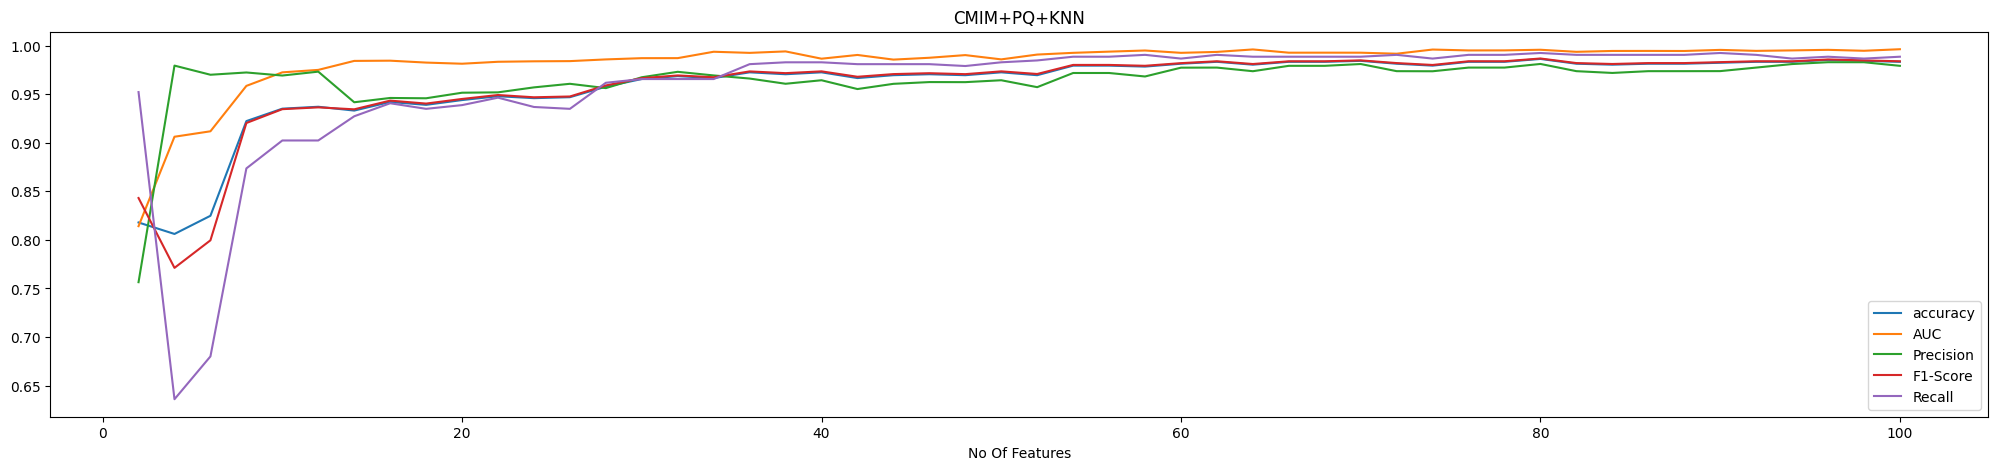

In [32]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_knn, label="accuracy")
plt.plot(auc_knn, label="AUC")
plt.plot(Precision_knn, label="Precision")
plt.plot(f1Score_knn, label="F1-Score")
plt.plot(Recall_knn , label="Recall")

plt.title("CMIM+PQ+KNN")
plt.xlabel("No Of Features")
plt.ylabel("")
plt.legend()
plt.show()

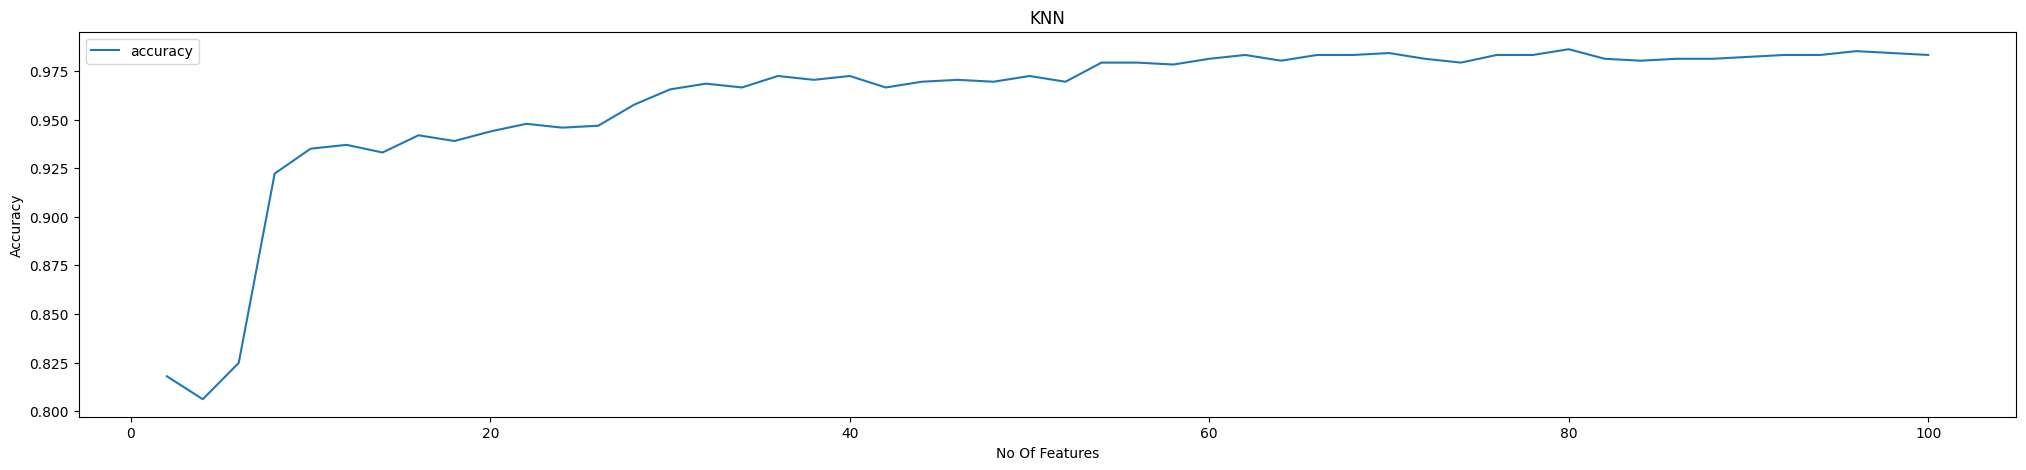

In [33]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_knn, label="accuracy")

plt.title("KNN")
plt.xlabel("No Of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

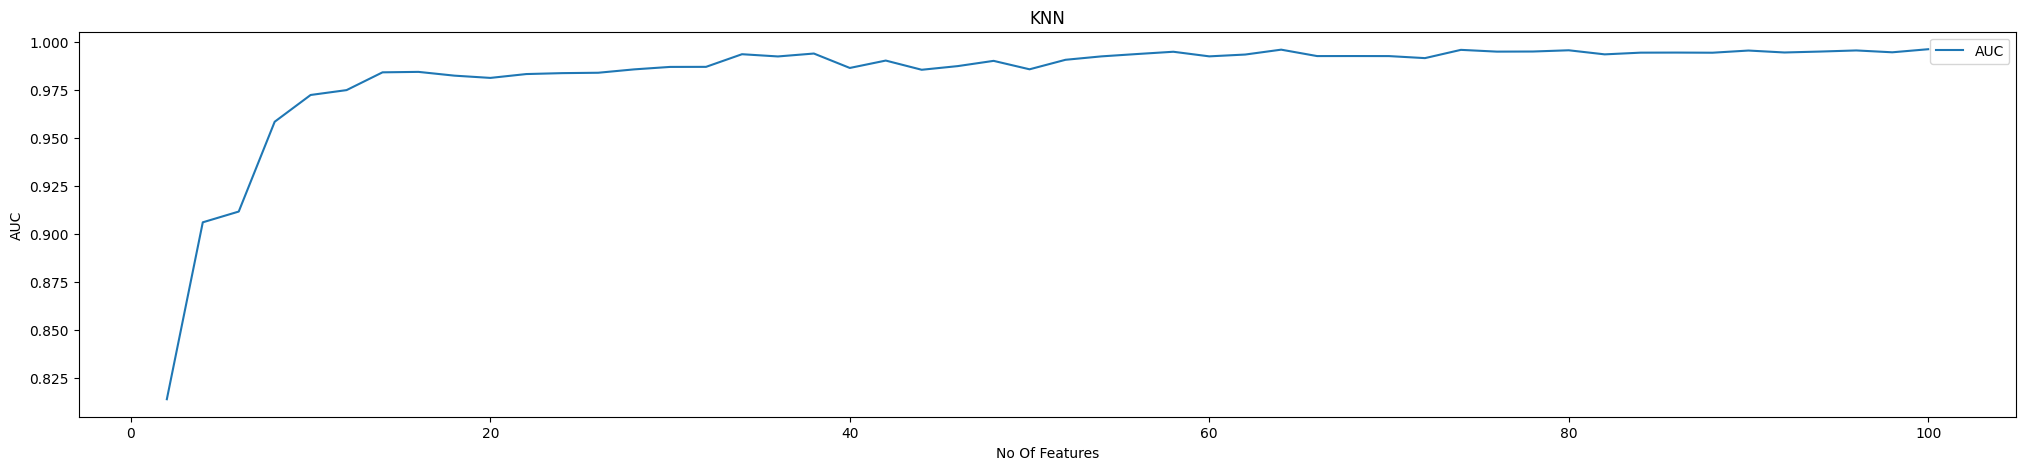

In [34]:
plt.figure(figsize=(25,5))
plt.plot(auc_knn, label="AUC")

plt.title("KNN")
plt.xlabel("No Of Features")
plt.ylabel("AUC")
plt.legend()
plt.show()

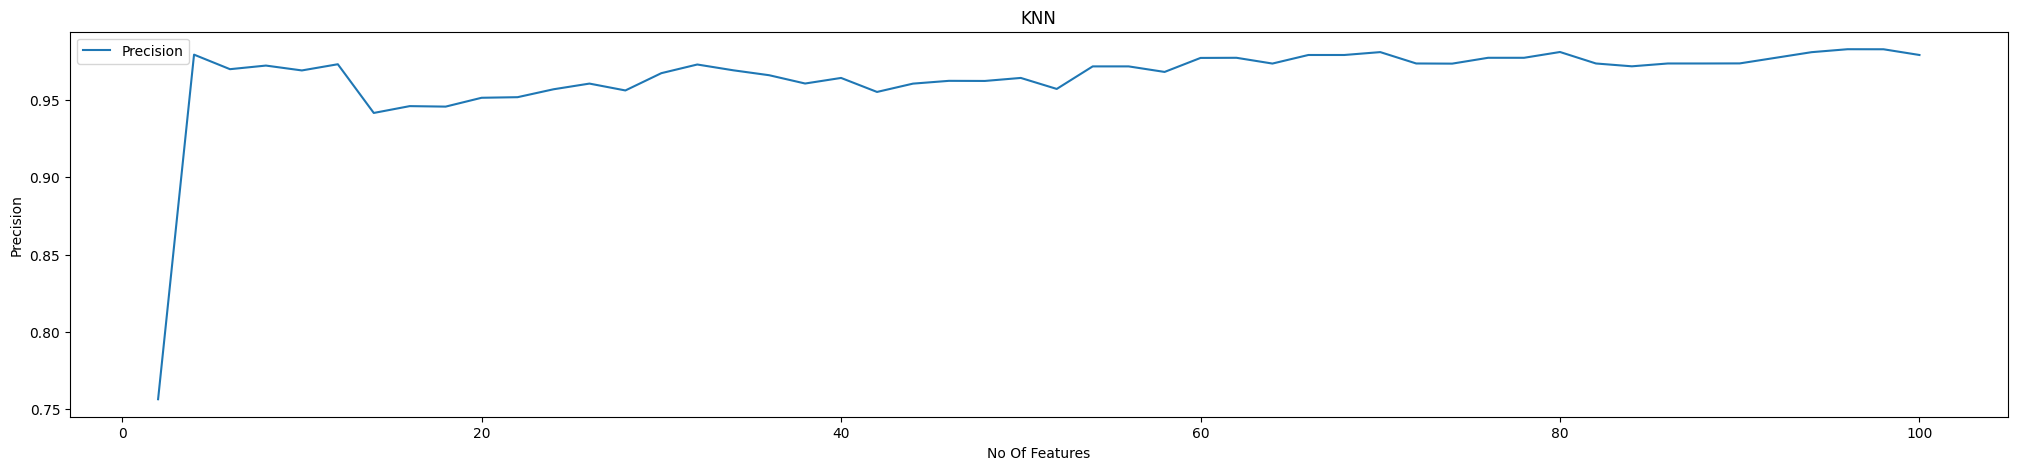

In [35]:
plt.figure(figsize=(25,5))
plt.plot(Precision_knn, label="Precision")

plt.title("KNN")
plt.xlabel("No Of Features")
plt.ylabel("Precision")
plt.legend()
plt.show()

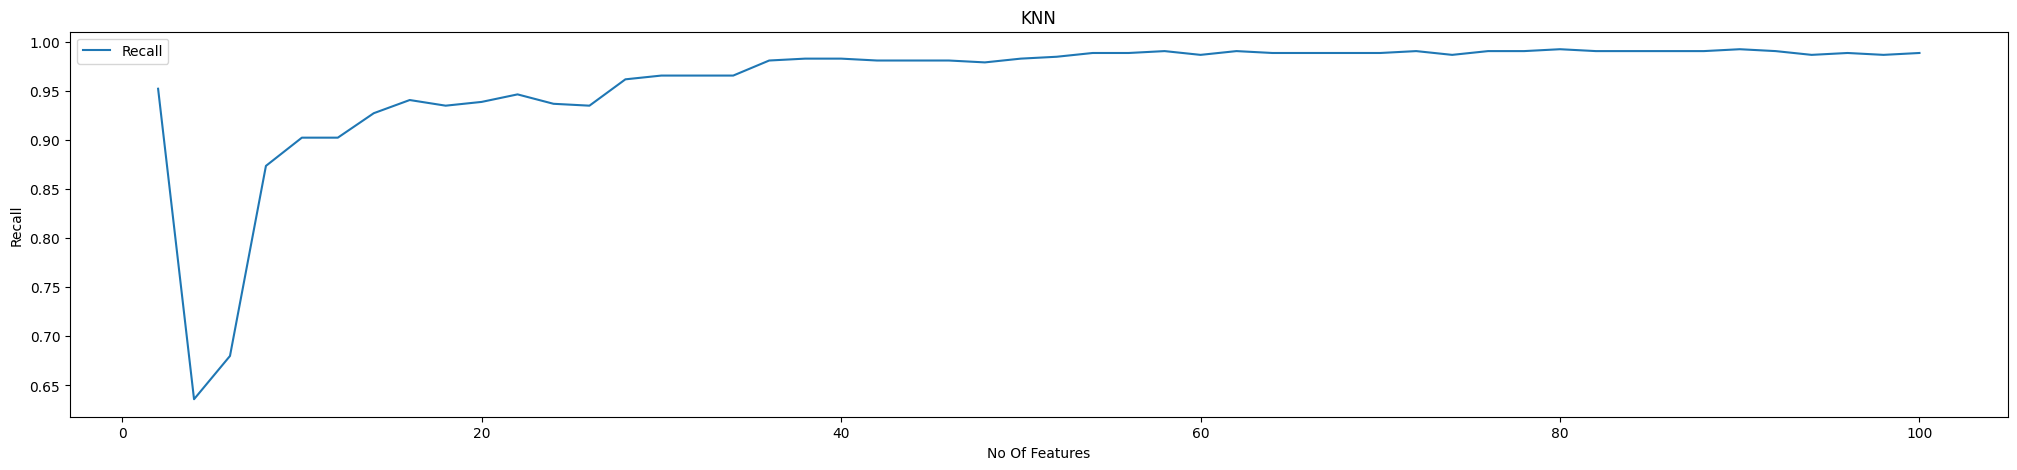

In [36]:
plt.figure(figsize=(25,5))
plt.plot(Recall_knn , label="Recall")

plt.title("KNN")
plt.xlabel("No Of Features")
plt.ylabel("Recall")
plt.legend()
plt.show()

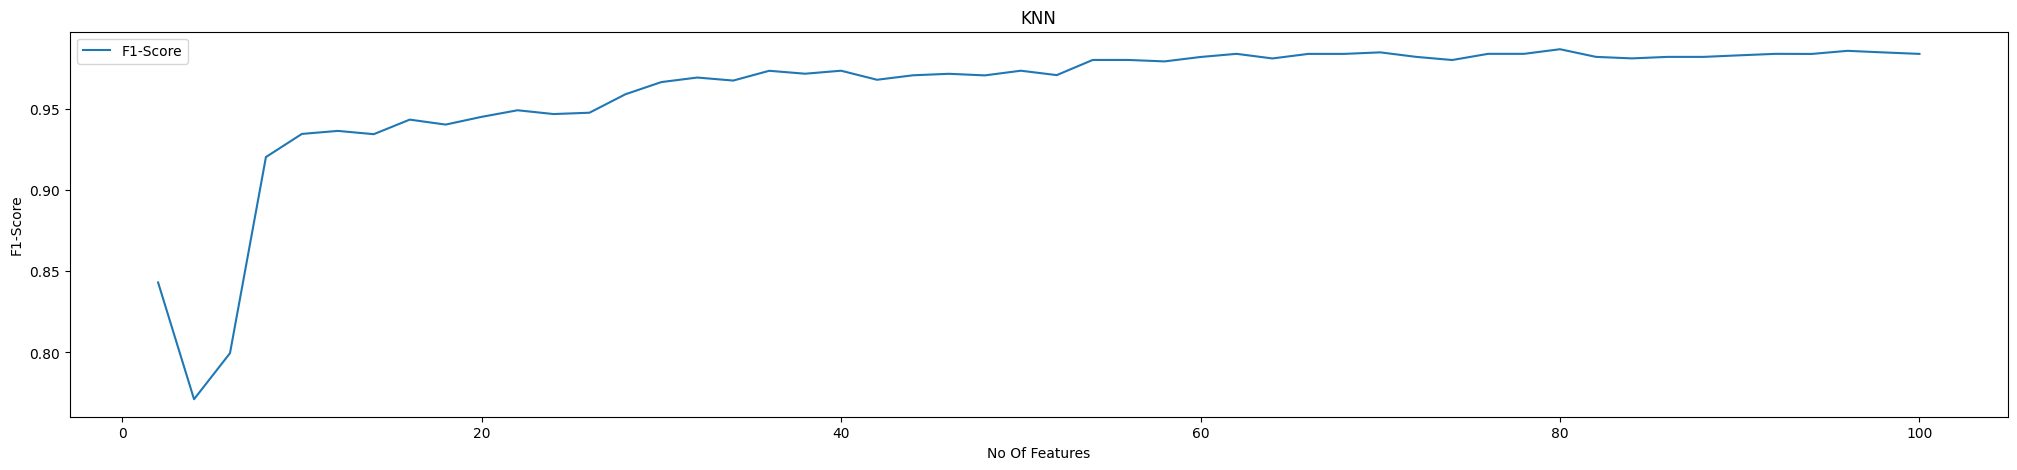

In [37]:
plt.figure(figsize=(25,5))
plt.plot(f1Score_knn, label="F1-Score")

plt.title("KNN")
plt.xlabel("No Of Features")
plt.ylabel("F1-Score")
plt.legend()
plt.show()